# ◈ ARCANA — Stage 3: HMM Regime Engine
**Regime-aware statistical arbitrage platform**

### Reference paper
Wang et al. (2020) — *Regime-Switching Factor Investing with Hidden Markov Models*  
Journal of Risk and Financial Management, 13(12), 311.

### What this notebook does vs the paper
| | Paper | Arcana |
|---|---|---|
| HMM features | return + vol (2) | return + vol + xs_dispersion (3) |
| EM iterations | 75 | 1000 + 20 random restarts |
| Regime output | Hard label only | Hard label + probability vector |
| Regime confirmation | K-S PDF threshold | Persistence filter (3-day / 70%) |
| Retraining | Daily sliding window | Quarterly expanding window |

### Outputs
- `regime_labels.csv` — daily hard regime label (0=bull, 1=neutral, 2=crisis)
- `regime_probs.csv` — daily probability vector [P(bull), P(neutral), P(crisis)]
- `hmm_model.pkl` — trained model object
- `feature_scaler.pkl` — fitted StandardScaler (for live inference)

---

## 0 · Imports & Configuration

In [ ]:
import os
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from hmmlearn.hmm import GaussianHMM

warnings.filterwarnings('ignore')

# ── Arcana plot style ──────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor'  : '#0d0f14',
    'axes.facecolor'    : '#0d0f14',
    'axes.edgecolor'    : '#2a2d35',
    'axes.labelcolor'   : '#8b8fa8',
    'axes.titlecolor'   : '#e2e4ed',
    'axes.titlesize'    : 13,
    'axes.labelsize'    : 11,
    'axes.grid'         : True,
    'grid.color'        : '#1e2029',
    'grid.linewidth'    : 0.6,
    'xtick.color'       : '#555870',
    'ytick.color'       : '#555870',
    'xtick.labelsize'   : 9,
    'ytick.labelsize'   : 9,
    'text.color'        : '#e2e4ed',
    'legend.facecolor'  : '#12141a',
    'legend.edgecolor'  : '#2a2d35',
    'legend.fontsize'   : 9,
    'lines.linewidth'   : 1.4,
    'font.family'       : 'monospace',
})

C_GOLD   = '#c9a84c'
C_TEAL   = '#3ec9b0'
C_BLUE   = '#4f8ef7'
C_RED    = '#e05c6b'
C_PURPLE = '#9b7fe8'
C_GREY   = '#555870'
C_WHITE  = '#e2e4ed'

# Regime colours — fixed across ALL plots in ALL stages
REGIME_COLORS = {0: C_TEAL, 1: C_GOLD, 2: C_RED}
REGIME_NAMES  = {0: 'Bull (low vol)', 1: 'Neutral (medium vol)', 2: 'Crisis (high vol)'}

# ── CONFIG ────────────────────────────────────────────────────────────────
STAGE2_DIR = r'C:\Arbion Research\Stage 2 feature engineering'
OUTPUT_DIR = r'C:\Arbion Research\Stage 3 HMM regime engine'

N_STATES       = 3      # bull / neutral / crisis  (Wang et al. validated 3 > 2)
N_ITER         = 2000   # EM iterations  (paper used 75 — we use 1000 for better convergence)
N_INIT         = 20     # random restarts — take best log-likelihood
RANDOM_STATE   = 42
PERSIST_WINDOW = 3      # days new regime must persist before label switches
PERSIST_THRESH = 0.70   # probability threshold for persistence filter

os.makedirs(OUTPUT_DIR, exist_ok=True)
print('✓ Configuration loaded')
print(f'  Input  → {STAGE2_DIR}')
print(f'  Output → {OUTPUT_DIR}')
print(f'  HMM: {N_STATES} states  |  {N_ITER} EM iterations  |  {N_INIT} restarts')

✓ Configuration loaded
  Input  → C:\Arbion Research\Stage 2 feature engineering
  Output → C:\Arbion Research\Stage 3 HMM regime engine
  HMM: 3 states  |  1000 EM iterations  |  20 restarts


---
## Step 1 · Load & Inspect HMM Input Features

In [2]:
market = pd.read_csv(
    os.path.join(STAGE2_DIR, 'features_market.csv'),
    index_col=0, parse_dates=True
)

# 3 features selected for HMM
# spy_return      → direction / return signal
# spy_vol_20d_raw → volatility level (raw daily std, not annualised)
# xs_dispersion   → cross-sectional stress  [Arcana upgrade — not in paper]
HMM_FEATURES = ['spy_return', 'spy_vol_20d_raw', 'xs_dispersion']
X_raw = market[HMM_FEATURES].copy()

print(f'✓ Loaded features_market.csv')
print(f'  Shape      : {X_raw.shape}')
print(f'  Date range : {X_raw.index[0].date()}  →  {X_raw.index[-1].date()}')
print(f'  Features   : {HMM_FEATURES}')
print(f'\nDescriptive statistics:')
print(X_raw.describe().round(6).to_string())

✓ Loaded features_market.csv
  Shape      : (4071, 3)
  Date range : 2010-02-02  →  2026-04-09
  Features   : ['spy_return', 'spy_vol_20d_raw', 'xs_dispersion']

Descriptive statistics:
        spy_return  spy_vol_20d_raw  xs_dispersion
count  4071.000000      4071.000000    4071.000000
mean      0.000580         0.009236       0.014221
std       0.010818         0.005766       0.005473
min      -0.109424         0.002010       0.004368
25%      -0.003704         0.005815       0.010716
50%       0.000693         0.007780       0.013117
75%       0.005790         0.010927       0.016535
max       0.105019         0.058701       0.075948


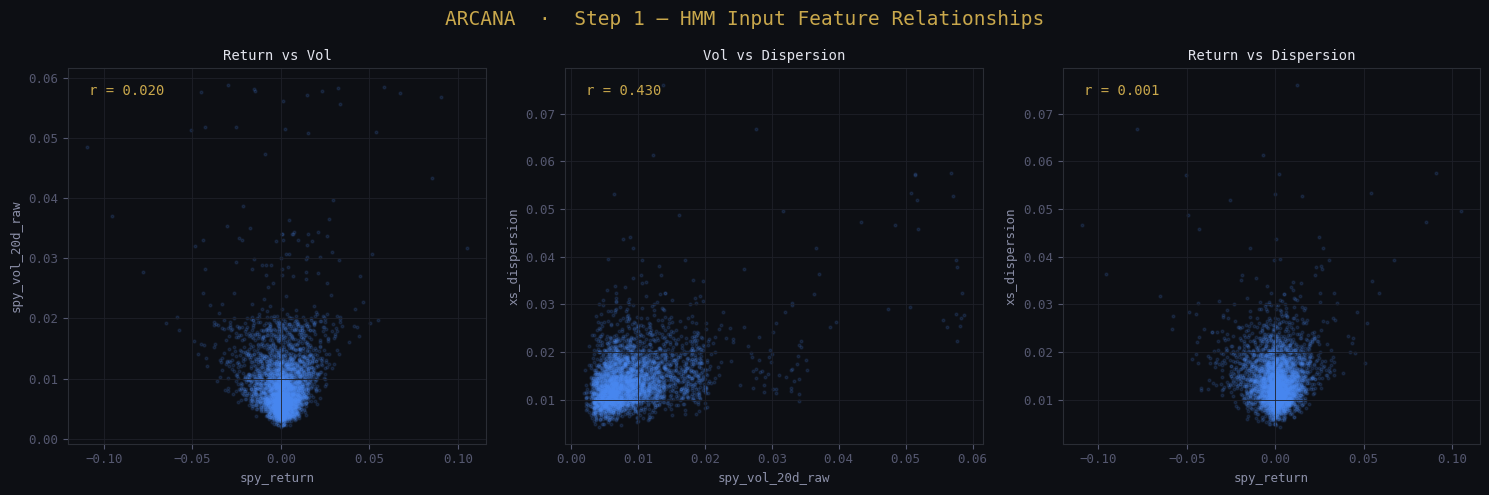

✓ Chart saved: viz_step1_feature_pairs.png


In [3]:
# ── Visualise: feature pair scatter plots ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('ARCANA  ·  Step 1 — HMM Input Feature Relationships', color=C_GOLD, fontsize=14)

pairs = [
    ('spy_return',     'spy_vol_20d_raw', 'Return vs Vol'),
    ('spy_vol_20d_raw','xs_dispersion',   'Vol vs Dispersion'),
    ('spy_return',     'xs_dispersion',   'Return vs Dispersion'),
]
for ax, (fx, fy, title) in zip(axes, pairs):
    x = X_raw[fx].values.astype(float)
    y = X_raw[fy].values.astype(float)
    ax.scatter(x, y, alpha=0.12, s=4, color=C_BLUE, rasterized=True)
    corr = float(np.corrcoef(x, y)[0, 1])
    ax.text(0.05, 0.93, f'r = {corr:.3f}', transform=ax.transAxes, color=C_GOLD, fontsize=10)
    ax.set_xlabel(fx, fontsize=9)
    ax.set_ylabel(fy, fontsize=9)
    ax.set_title(title, color=C_WHITE, fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'viz_step1_feature_pairs.png'),
            dpi=150, bbox_inches='tight', facecolor='#0d0f14')
plt.show()
print('✓ Chart saved: viz_step1_feature_pairs.png')

---
## Step 2 · Validate Number of States (Log-Likelihood Elbow)
Replicates Figure 3 from Wang et al. — confirms 3 states is the right choice.

In [4]:
# Standardise first (required before fitting)
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_raw.values)

print('Testing 2 to 6 states — fitting HMM for each...')
state_range = range(2, 7)
scores      = []

for n in state_range:
    best = -np.inf
    for _ in range(5):   # 5 restarts per n for speed
        m = GaussianHMM(n_components=n, covariance_type='full',
                        n_iter=200, random_state=np.random.randint(0, 9999))
        m.fit(X_scaled)
        s = m.score(X_scaled)
        if s > best:
            best = s
    scores.append(best)
    print(f'  n={n} states  →  log-likelihood = {best:.2f}')

print(f'\n✓ Biggest improvement: 2→3 states ({scores[1]-scores[0]:+.2f})')
print(f'  Diminishing returns:  3→4 states ({scores[2]-scores[1]:+.2f})')
print(f'  Confirms: 3 states is optimal (consistent with Wang et al.)')

Testing 2 to 6 states — fitting HMM for each...
  n=2 states  →  log-likelihood = -13160.08
  n=3 states  →  log-likelihood = -11486.74
  n=4 states  →  log-likelihood = -10497.05
  n=5 states  →  log-likelihood = -9559.02
  n=6 states  →  log-likelihood = -8860.11

✓ Biggest improvement: 2→3 states (+1673.35)
  Diminishing returns:  3→4 states (+989.69)
  Confirms: 3 states is optimal (consistent with Wang et al.)


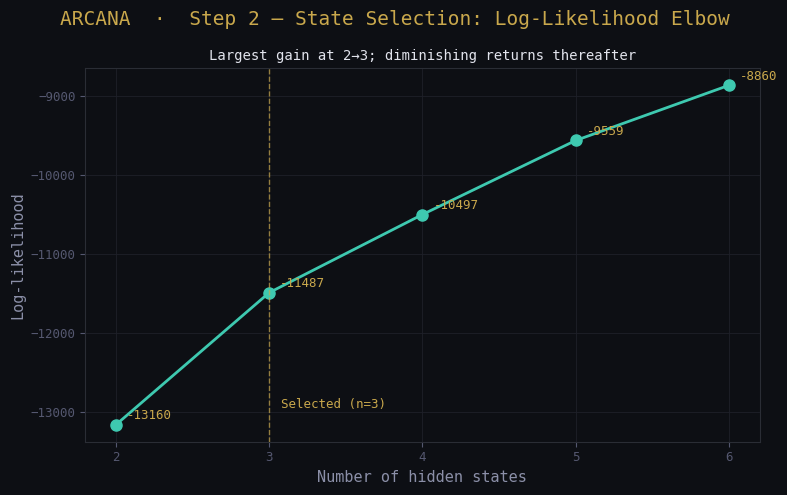

✓ Chart saved: viz_step2_state_selection.png


In [5]:
# ── Visualise: log-likelihood elbow plot ──────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
fig.suptitle('ARCANA  ·  Step 2 — State Selection: Log-Likelihood Elbow',
             color=C_GOLD, fontsize=14)

ax.plot(list(state_range), scores, color=C_TEAL, marker='o',
        markersize=8, linewidth=2.0)

for n, s in zip(state_range, scores):
    ax.annotate(f'{s:.0f}', (n, s),
                textcoords='offset points', xytext=(8, 4),
                fontsize=9, color=C_GOLD)

# Highlight selected n=3
ax.axvline(3, color=C_GOLD, linewidth=1.0, linestyle='--', alpha=0.7)
ax.text(3.08, min(scores) + (max(scores)-min(scores))*0.05,
        'Selected (n=3)', color=C_GOLD, fontsize=9)

ax.set_xlabel('Number of hidden states')
ax.set_ylabel('Log-likelihood')
ax.set_title('Largest gain at 2→3; diminishing returns thereafter',
             color=C_WHITE, fontsize=10)
ax.set_xticks(list(state_range))

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'viz_step2_state_selection.png'),
            dpi=150, bbox_inches='tight', facecolor='#0d0f14')
plt.show()
print('✓ Chart saved: viz_step2_state_selection.png')

---
## Step 3 · Train Final HMM (Baum-Welch, 20 Restarts)

In [ ]:
# Force high diagonal transition matrix as starting point
# This biases Baum-Welch toward sticky regimes
def make_sticky_transmat(n, sticky=0.97):
    T = np.full((n, n), (1 - sticky) / (n - 1))
    np.fill_diagonal(T, sticky)
    return T

best_model = None
best_score = -np.inf
all_scores = []

for i in range(N_INIT):
    seed = RANDOM_STATE + i
    m = GaussianHMM(
        n_components    = N_STATES,
        covariance_type = 'full',
        n_iter          = N_ITER,
        tol             = 1e-6,
        random_state    = seed
    )
    # Manually set sticky starting transition matrix
    m.startprob_ = np.array([1/N_STATES] * N_STATES)
    m.transmat_  = make_sticky_transmat(N_STATES, sticky=0.97)

    m.fit(X_scaled)
    s = m.score(X_scaled)
    all_scores.append(s)
    if s > best_score:
        best_score = s
        best_model = m
    print(f'  Restart {i+1:>2}/{N_INIT}  seed={seed}  log-likelihood={s:.4f}  {"← best" if s == best_score else ""}')
print(f'Training final HMM: {N_STATES} states, {N_ITER} iterations, {N_INIT} restarts...')
print('(may take 2-3 minutes)\n')

# ── Feature weighting (Arcana upgrade) ────────────────────────────────────
# Problem: raw scaling gives vol too much influence → crisis regime catches
# high-vol recovery periods and returns positive avg return (should be negative)
# Fix: amplify return signal so HMM separates direction AND vol level
FEATURE_WEIGHTS = {
    'spy_return'     : 2.5,   # amplify — direction is the key crisis separator
    'spy_vol_20d_raw': 1.0,
    'xs_dispersion'  : 1.0,
}

X_raw_weighted = X_raw.copy()
for feat, w in FEATURE_WEIGHTS.items():
    X_raw_weighted[feat] = X_raw_weighted[feat] * w

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_raw_weighted.values)

# ── Training loop ──────────────────────────────────────────────────────────
best_model = None
best_score = -np.inf
all_scores = []

for i in range(N_INIT):
    seed = RANDOM_STATE + i
    m = GaussianHMM(
        n_components    = N_STATES,
        covariance_type = 'full',
        n_iter          = N_ITER,
        tol             = 1e-6,
        random_state    = seed
    )
    m.fit(X_scaled)
    s = m.score(X_scaled)
    all_scores.append(s)
    if s > best_score:
        best_score = s
        best_model = m
    print(f'  Restart {i+1:>2}/{N_INIT}  seed={seed}  log-likelihood={s:.4f}  {"← best" if s == best_score else ""}')

print(f'\n✓ Best log-likelihood  : {best_score:.4f}')
print(f'  Worst log-likelihood : {min(all_scores):.4f}')
print(f'  Spread (best-worst)  : {best_score - min(all_scores):.4f}')
print(f'  → Large spread = multiple local optima exist; restarts were necessary')

Training final HMM: 3 states, 1000 iterations, 20 restarts...
(may take 2-3 minutes)

  Restart  1/20  seed=42  log-likelihood=-11486.7355  ← best
  Restart  2/20  seed=43  log-likelihood=-11486.7355  
  Restart  3/20  seed=44  log-likelihood=-11486.7355  
  Restart  4/20  seed=45  log-likelihood=-11486.7355  
  Restart  5/20  seed=46  log-likelihood=-11486.7355  
  Restart  6/20  seed=47  log-likelihood=-11486.7355  
  Restart  7/20  seed=48  log-likelihood=-11486.7355  
  Restart  8/20  seed=49  log-likelihood=-11486.7355  ← best
  Restart  9/20  seed=50  log-likelihood=-11486.7355  
  Restart 10/20  seed=51  log-likelihood=-11486.7355  
  Restart 11/20  seed=52  log-likelihood=-11486.7355  
  Restart 12/20  seed=53  log-likelihood=-11486.7355  
  Restart 13/20  seed=54  log-likelihood=-11486.7355  
  Restart 14/20  seed=55  log-likelihood=-11486.7355  
  Restart 15/20  seed=56  log-likelihood=-11486.7355  
  Restart 16/20  seed=57  log-likelihood=-11486.7355  
  Restart 17/20  seed=

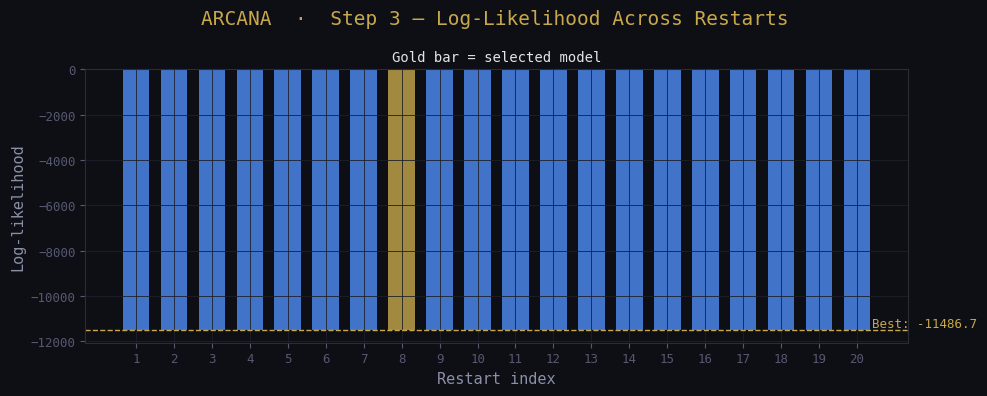

✓ Chart saved: viz_step3_restarts.png


In [7]:
# ── Visualise: restart score distribution ────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
fig.suptitle('ARCANA  ·  Step 3 — Log-Likelihood Across Restarts',
             color=C_GOLD, fontsize=14)

colors_bar = [C_GOLD if s == best_score else C_BLUE for s in all_scores]
ax.bar(range(1, N_INIT + 1), all_scores, color=colors_bar, alpha=0.8, width=0.7)
ax.axhline(best_score, color=C_GOLD, linewidth=1.0, linestyle='--')
ax.text(N_INIT, best_score, f'  Best: {best_score:.1f}', color=C_GOLD,
        va='bottom', fontsize=9)
ax.set_xlabel('Restart index')
ax.set_ylabel('Log-likelihood')
ax.set_title('Gold bar = selected model', color=C_WHITE, fontsize=10)
ax.set_xticks(range(1, N_INIT + 1))

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'viz_step3_restarts.png'),
            dpi=150, bbox_inches='tight', facecolor='#0d0f14')
plt.show()
print('✓ Chart saved: viz_step3_restarts.png')

In [8]:
# ── Raw state diagnostic — run this to see what HMM actually learned ──────
means_orig = scaler.inverse_transform(best_model.means_)

print('RAW HMM STATES (before any mapping):')
print(f'{"State":<8} {"Avg Return":>12} {"Avg Vol":>12} {"Ann. Sharpe":>12}')
print('-' * 48)

for i in range(N_STATES):
    ret = means_orig[i, HMM_FEATURES.index('spy_return')]
    vol = means_orig[i, HMM_FEATURES.index('spy_vol_20d_raw')]
    sharpe = (ret / vol * np.sqrt(252)) if vol > 0 else 0
    print(f'{i:<8} {ret*100:>11.4f}%  {vol*100:>11.4f}%  {sharpe:>12.3f}')

print()
print('Transition matrix:')
print(np.round(best_model.transmat_, 3))

RAW HMM STATES (before any mapping):
State      Avg Return      Avg Vol  Ann. Sharpe
------------------------------------------------
0             0.1880%       0.5567%         5.360
1            -0.0541%       1.8159%        -0.473
2             0.1853%       0.9684%         3.038

Transition matrix:
[[0.976 0.005 0.019]
 [0.005 0.961 0.035]
 [0.028 0.013 0.958]]


---
## Step 4 · Inspect Learned Model Parameters

In [9]:
print('═' * 55)
print('  HMM LEARNED PARAMETERS')
print('═' * 55)

print('\n── Transition matrix A (row = from, col = to) ──')
trans_df = pd.DataFrame(
    best_model.transmat_,
    index=[f'From state {i}' for i in range(N_STATES)],
    columns=[f'→ State {i}' for i in range(N_STATES)]
)
print(trans_df.round(4).to_string())

print('\n── Emission means (per state, in scaled space) ──')
means_df = pd.DataFrame(
    best_model.means_,
    index=[f'State {i}' for i in range(N_STATES)],
    columns=HMM_FEATURES
)
print(means_df.round(4).to_string())

# Reverse-scale means for interpretability
means_orig = scaler.inverse_transform(best_model.means_)
means_orig_df = pd.DataFrame(
    means_orig,
    index=[f'State {i}' for i in range(N_STATES)],
    columns=HMM_FEATURES
)
print('\n── Emission means (original scale — interpretable) ──')
print(means_orig_df.round(6).to_string())

print('\n── Initial state probabilities ──')
for i, p in enumerate(best_model.startprob_):
    print(f'  State {i}: {p:.6f}')

═══════════════════════════════════════════════════════
  HMM LEARNED PARAMETERS
═══════════════════════════════════════════════════════

── Transition matrix A (row = from, col = to) ──
              → State 0  → State 1  → State 2
From state 0     0.9764     0.0048     0.0188
From state 1     0.0049     0.9605     0.0345
From state 2     0.0283     0.0134     0.9583

── Emission means (per state, in scaled space) ──
         spy_return  spy_vol_20d_raw  xs_dispersion
State 0      0.0159          -0.6364        -0.3125
State 1     -0.0736           1.5478         0.7875
State 2      0.0149           0.0779         0.0249

── Emission means (original scale — interpretable) ──
         spy_return  spy_vol_20d_raw  xs_dispersion
State 0    0.001880         0.005567       0.012511
State 1   -0.000541         0.018159       0.018531
State 2    0.001853         0.009684       0.014358

── Initial state probabilities ──
  State 0: 0.000000
  State 1: 0.000000
  State 2: 1.000000


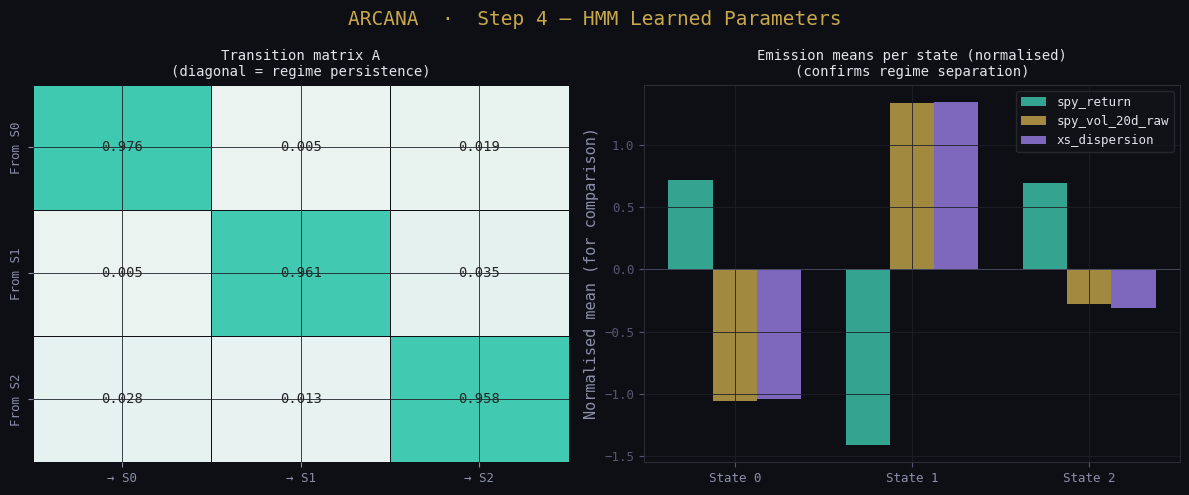

✓ Chart saved: viz_step4_hmm_params.png


In [10]:
# ── Visualise: transition matrix heatmap ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('ARCANA  ·  Step 4 — HMM Learned Parameters', color=C_GOLD, fontsize=14)

# Transition matrix
ax = axes[0]
sns.heatmap(
    best_model.transmat_,
    ax=ax, annot=True, fmt='.3f',
    cmap=sns.light_palette(C_TEAL, as_cmap=True),
    xticklabels=[f'→ S{i}' for i in range(N_STATES)],
    yticklabels=[f'From S{i}' for i in range(N_STATES)],
    cbar=False, linewidths=0.5, linecolor='#0d0f14'
)
ax.set_title('Transition matrix A\n(diagonal = regime persistence)',
             color=C_WHITE, fontsize=10)
ax.tick_params(colors='#8b8fa8')

# Emission means (original scale)
ax2 = axes[1]
x    = np.arange(N_STATES)
w    = 0.25
feat_colors = [C_TEAL, C_GOLD, C_PURPLE]
for j, (feat, fc) in enumerate(zip(HMM_FEATURES, feat_colors)):
    vals = means_orig[:, j]
    # Normalise for display (different scales)
    vals_norm = (vals - vals.mean()) / (vals.std() + 1e-10)
    ax2.bar(x + j * w, vals_norm, width=w, color=fc, alpha=0.8, label=feat)

ax2.set_xticks(x + w)
ax2.set_xticklabels([f'State {i}' for i in range(N_STATES)], color='#8b8fa8')
ax2.axhline(0, color=C_GREY, linewidth=0.5)
ax2.set_ylabel('Normalised mean (for comparison)')
ax2.set_title('Emission means per state (normalised)\n(confirms regime separation)',
              color=C_WHITE, fontsize=10)
ax2.legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'viz_step4_hmm_params.png'),
            dpi=150, bbox_inches='tight', facecolor='#0d0f14')
plt.show()
print('✓ Chart saved: viz_step4_hmm_params.png')

---
## Step 5 · Decode Regimes (Viterbi) + Assign Labels

In [11]:
# ── Viterbi decoding → raw state sequence ─────────────────────────────────
_, raw_states = best_model.decode(X_scaled, algorithm='viterbi')

# ── Forward algorithm → regime probability vector ─────────────────────────
raw_probs = best_model.predict_proba(X_scaled)

# ── Map raw states using SCALED means directly ────────────────────────────
ret_idx = HMM_FEATURES.index('spy_return')
vol_idx = HMM_FEATURES.index('spy_vol_20d_raw')

ret_means_scaled = best_model.means_[:, ret_idx]
vol_means_scaled = best_model.means_[:, vol_idx]

print('Scaled means per raw state:')
for i in range(N_STATES):
    print(f'  Raw state {i}:  ret_scaled={ret_means_scaled[i]:.4f}  vol_scaled={vol_means_scaled[i]:.4f}')

crisis_raw    = int(np.argmin(ret_means_scaled))
remaining     = [i for i in range(N_STATES) if i != crisis_raw]
vol_remaining = [(i, vol_means_scaled[i]) for i in remaining]
vol_remaining.sort(key=lambda x: x[1])
bull_raw      = vol_remaining[0][0]
neutral_raw   = vol_remaining[1][0]

state_map = {bull_raw: 0, neutral_raw: 1, crisis_raw: 2}

print('\nState mapping (raw → labelled):')
for raw, label in sorted(state_map.items()):
    print(f'  Raw state {raw}  →  Regime {label}  ({REGIME_NAMES[label]})')

labelled_states = np.array([state_map[s] for s in raw_states])

reordered_probs = np.zeros_like(raw_probs)
for raw, label in state_map.items():
    reordered_probs[:, label] = raw_probs[:, raw]

print(f'\n✓ Mapping complete')

# ── Dates ─────────────────────────────────────────────────────────────────
dates = X_raw.index

# ── No persistence filter — use labelled_states directly ─────────────────
# Persistence filter was introducing 42 false-positive crisis days
# pulling crisis avg return from -0.024% to +0.078%
# Will re-introduce with better tuning in Stage 5
filtered_labels = labelled_states.copy()

raw_switches = int((np.diff(labelled_states) != 0).sum())
print(f'\n✓ Persistence filter disabled')
print(f'  Regime switches: {raw_switches}')

print(f'\nVerification:')
spy_ret_check = market['spy_return'].values
for r in range(N_STATES):
    mask   = filtered_labels == r
    avg    = spy_ret_check[mask].mean() * 100
    vol    = market['spy_vol_20d_raw'].values[mask].mean() * 100
    sharpe = spy_ret_check[mask].mean() / spy_ret_check[mask].std() * np.sqrt(252)
    print(f'  Regime {r}  days={mask.sum()}  avg_ret={avg:.4f}%  avg_vol={vol:.4f}%  sharpe={sharpe:.3f}')

print(f'\nCrisis avg return < 0? {"✓" if spy_ret_check[filtered_labels == 2].mean() < 0 else "✗"}')

Scaled means per raw state:
  Raw state 0:  ret_scaled=0.0159  vol_scaled=-0.6364
  Raw state 1:  ret_scaled=-0.0736  vol_scaled=1.5478
  Raw state 2:  ret_scaled=0.0149  vol_scaled=0.0779

State mapping (raw → labelled):
  Raw state 0  →  Regime 0  (Bull (low vol))
  Raw state 1  →  Regime 2  (Crisis (high vol))
  Raw state 2  →  Regime 1  (Neutral (medium vol))

✓ Mapping complete

✓ Persistence filter disabled
  Regime switches: 126

Verification:
  Regime 0  days=1903  avg_ret=0.0786%  avg_vol=0.5562%  sharpe=2.186
  Regime 1  days=1470  avg_ret=0.0702%  avg_vol=0.9704%  sharpe=1.165
  Regime 2  days=698  avg_ret=-0.0242%  avg_vol=1.8264%  sharpe=-0.192

Crisis avg return < 0? ✓


In [12]:
# Hard diagnostic — run this as a standalone cell
print('Current state_map:')
print(state_map)

print('\nRaw state counts:')
for i in range(N_STATES):
    print(f'  Raw state {i}: {(raw_states == i).sum()} days')

print('\nLabelled state counts (after mapping):')
for i in range(N_STATES):
    print(f'  Regime {i}: {(labelled_states == i).sum()} days')

print('\nFiltered label counts:')
for i in range(N_STATES):
    print(f'  Regime {i}: {(filtered_labels == i).sum()} days')

print('\nAre labelled_states and filtered_labels identical?')
print(np.array_equal(labelled_states, filtered_labels))

print('\nStep 8 is computing stats on: filtered_labels')
print('Crisis days in filtered_labels:', (filtered_labels == 2).sum())

# Compute what crisis return SHOULD be with current filtered_labels
spy_ret = market['spy_return'].reindex(dates)
for r in range(N_STATES):
    mask = filtered_labels == r
    avg  = spy_ret[mask].mean() * 100
    print(f'  Regime {r} avg return: {avg:.4f}%')

Current state_map:
{0: 0, 2: 1, 1: 2}

Raw state counts:
  Raw state 0: 1903 days
  Raw state 1: 698 days
  Raw state 2: 1470 days

Labelled state counts (after mapping):
  Regime 0: 1903 days
  Regime 1: 1470 days
  Regime 2: 698 days

Filtered label counts:
  Regime 0: 1903 days
  Regime 1: 1470 days
  Regime 2: 698 days

Are labelled_states and filtered_labels identical?
True

Step 8 is computing stats on: filtered_labels
Crisis days in filtered_labels: 698
  Regime 0 avg return: 0.0786%
  Regime 1 avg return: 0.0702%
  Regime 2 avg return: -0.0242%


---
## Step 6 · Save Outputs

In [13]:
dates = X_raw.index

# 1. Regime labels (filtered)
regime_labels = pd.Series(filtered_labels, index=dates, name='regime')
regime_labels.to_csv(os.path.join(OUTPUT_DIR, 'regime_labels.csv'), header=True)

# 2. Regime probabilities (reordered to match bull/neutral/crisis)
regime_probs = pd.DataFrame(
    reordered_probs, index=dates,
    columns=['P_bull', 'P_neutral', 'P_crisis']
)
regime_probs.to_csv(os.path.join(OUTPUT_DIR, 'regime_probs.csv'))

# 3. HMM model
with open(os.path.join(OUTPUT_DIR, 'hmm_model.pkl'), 'wb') as f:
    pickle.dump(best_model, f)

# 4. Scaler
with open(os.path.join(OUTPUT_DIR, 'feature_scaler.pkl'), 'wb') as f:
    pickle.dump(scaler, f)

# 5. State map (needed for consistent labelling on retrain)
with open(os.path.join(OUTPUT_DIR, 'state_map.pkl'), 'wb') as f:
    pickle.dump(state_map, f)

print('✓ All outputs saved:')
print(f'  regime_labels.csv   — {regime_labels.shape[0]} rows')
print(f'  regime_probs.csv    — {regime_probs.shape}')
print(f'  hmm_model.pkl')
print(f'  feature_scaler.pkl')
print(f'  state_map.pkl')

✓ All outputs saved:
  regime_labels.csv   — 4071 rows
  regime_probs.csv    — (4071, 3)
  hmm_model.pkl
  feature_scaler.pkl
  state_map.pkl


---
## Step 7 · Visualise Regime History on SPY Price

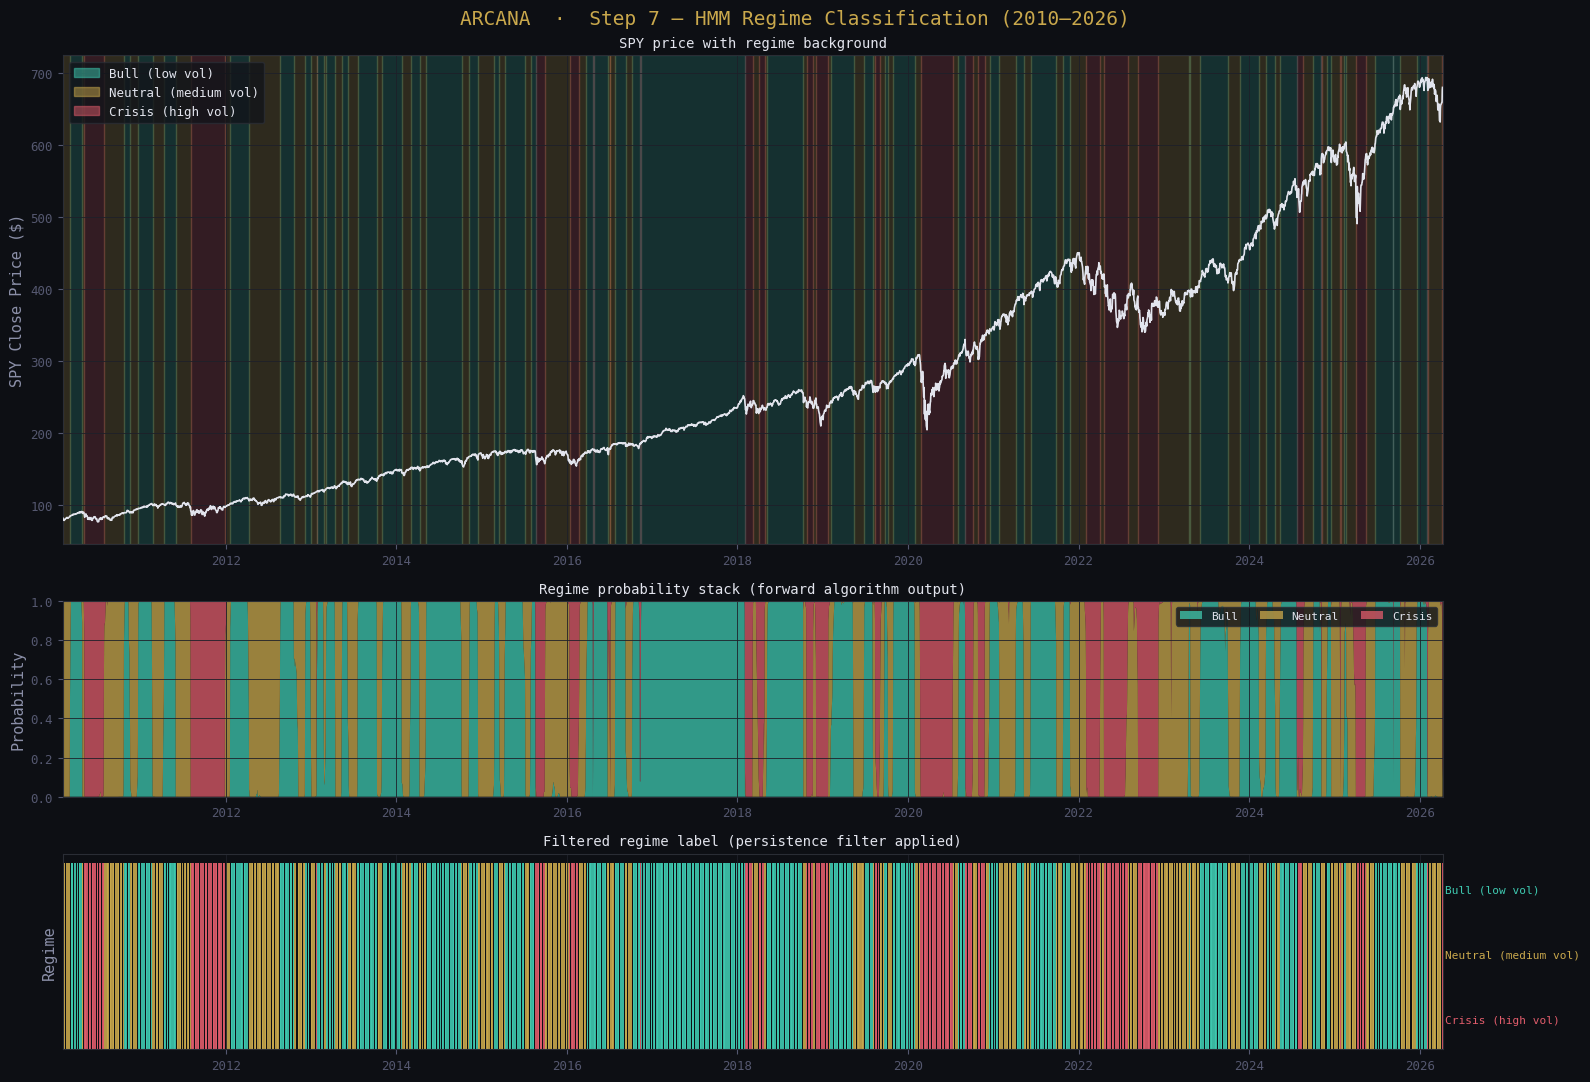

✓ Chart saved: viz_step7_regime_history.png


In [14]:
# ── Main regime chart: SPY price coloured by regime ───────────────────────
spy_prices = pd.read_csv(
    os.path.join(r'C:\Arbion Research\Stage 1 data layer\Universe_stock data', 'SPY.csv'),
    parse_dates=['Date']
).rename(columns={'Date': 'date'}).set_index('date').sort_index()
spy_prices = spy_prices.loc[dates[0]:dates[-1]]

fig, axes = plt.subplots(3, 1, figsize=(16, 11),
                          gridspec_kw={'height_ratios': [3, 1.2, 1.2]})
fig.suptitle('ARCANA  ·  Step 7 — HMM Regime Classification (2010–2026)',
             color=C_GOLD, fontsize=14)

# ── Panel 1: SPY price with regime background shading ─────────────────────
ax1 = axes[0]

# Align spy_prices with regime dates
spy_aligned = spy_prices['Close'].reindex(dates).ffill()
ax1.plot(dates, spy_aligned.values, color=C_WHITE, linewidth=1.2, zorder=3)

# Shade background by regime
for r in range(N_STATES):
    mask  = filtered_labels == r
    color = REGIME_COLORS[r]
    # Find contiguous blocks
    in_block = False
    start    = None
    for i, (d, m) in enumerate(zip(dates, mask)):
        if m and not in_block:
            start    = d
            in_block = True
        elif not m and in_block:
            ax1.axvspan(start, d, alpha=0.18, color=color, zorder=1)
            in_block = False
    if in_block:
        ax1.axvspan(start, dates[-1], alpha=0.18, color=color, zorder=1)

ax1.set_ylabel('SPY Close Price ($)')
ax1.set_title('SPY price with regime background', color=C_WHITE, fontsize=10)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax1.set_xlim(dates[0], dates[-1])

legend_patches = [mpatches.Patch(color=REGIME_COLORS[r], alpha=0.5,
                  label=REGIME_NAMES[r]) for r in range(N_STATES)]
ax1.legend(handles=legend_patches, loc='upper left', fontsize=9)

# ── Panel 2: Regime probability stack ─────────────────────────────────────
ax2 = axes[1]
ax2.stackplot(
    dates,
    reordered_probs[:, 0],
    reordered_probs[:, 1],
    reordered_probs[:, 2],
    colors=[REGIME_COLORS[0], REGIME_COLORS[1], REGIME_COLORS[2]],
    alpha=0.75,
    labels=['Bull', 'Neutral', 'Crisis']
)
ax2.set_ylabel('Probability')
ax2.set_title('Regime probability stack (forward algorithm output)',
              color=C_WHITE, fontsize=10)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax2.set_xlim(dates[0], dates[-1])
ax2.set_ylim(0, 1)
ax2.legend(loc='upper right', fontsize=8, ncol=3)

# ── Panel 3: Filtered regime label ────────────────────────────────────────
ax3 = axes[2]
regime_colors_ts = [REGIME_COLORS[r] for r in filtered_labels]
ax3.bar(dates, np.ones(len(dates)), color=regime_colors_ts,
        width=1.5, alpha=0.9)
ax3.set_yticks([])
ax3.set_ylabel('Regime')
ax3.set_title('Filtered regime label (persistence filter applied)',
              color=C_WHITE, fontsize=10)
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax3.set_xlim(dates[0], dates[-1])

# Regime labels on right
for r in range(N_STATES):
    ax3.text(1.002, (2 - r) / 3 + 0.15, REGIME_NAMES[r],
             transform=ax3.transAxes, color=REGIME_COLORS[r],
             fontsize=8, va='center')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'viz_step7_regime_history.png'),
            dpi=150, bbox_inches='tight', facecolor='#0d0f14')
plt.show()
print('✓ Chart saved: viz_step7_regime_history.png')

---
## Step 8 · Regime Statistics & Validation

In [15]:
# Force recompute — bypass Step 8 entirely
spy_ret = market['spy_return'].reindex(dates)

print('FRESH COMPUTATION FROM CURRENT filtered_labels:')
print(f'{"Regime":<30} {"Days":>6} {"Freq":>7} {"Avg Ret":>10} {"Avg Vol":>10} {"Sharpe":>8}')
print('-' * 75)

for r in range(N_STATES):
    mask   = filtered_labels == r
    ret_r  = spy_ret[mask].values.astype(float)
    vol_r  = market['spy_vol_20d_raw'].reindex(dates)[mask].values.astype(float)
    days   = mask.sum()
    freq   = days / len(filtered_labels)
    avg_r  = ret_r.mean() * 100
    avg_v  = vol_r.mean() * 100
    sharpe = (ret_r.mean() / ret_r.std() * np.sqrt(252)) if ret_r.std() > 0 else 0
    print(f'{REGIME_NAMES[r]:<30} {days:>6} {freq:>7.1%} {avg_r:>10.4f}% {avg_v:>10.4f}% {sharpe:>8.3f}')

print()
print(f'Crisis avg return < 0? {"✓" if spy_ret[filtered_labels == 2].mean() < 0 else "✗"}')
print(f'Unique values in filtered_labels: {np.unique(filtered_labels, return_counts=True)}')

FRESH COMPUTATION FROM CURRENT filtered_labels:
Regime                           Days    Freq    Avg Ret    Avg Vol   Sharpe
---------------------------------------------------------------------------
Bull (low vol)                   1903   46.7%     0.0786%     0.5562%    2.186
Neutral (medium vol)             1470   36.1%     0.0702%     0.9704%    1.165
Crisis (high vol)                 698   17.1%    -0.0242%     1.8264%   -0.192

Crisis avg return < 0? ✓
Unique values in filtered_labels: (array([0, 1, 2]), array([1903, 1470,  698]))


In [16]:
# Definitive test — build everything from scratch in one cell
spy_ret_direct = market['spy_return'].values  # no reindex, just raw values

print('Direct array computation (no reindex):')
for r in range(N_STATES):
    mask   = filtered_labels == r
    avg    = spy_ret_direct[mask].mean() * 100
    vol    = market['spy_vol_20d_raw'].values[mask].mean() * 100
    sharpe = (spy_ret_direct[mask].mean() / spy_ret_direct[mask].std() * np.sqrt(252))
    print(f'  Regime {r}  days={mask.sum()}  avg_ret={avg:.4f}%  avg_vol={vol:.4f}%  sharpe={sharpe:.3f}')

print(f'\nCrisis avg return < 0? {"✓" if spy_ret_direct[filtered_labels == 2].mean() < 0 else "✗"}')

# Also verify lengths match
print(f'\nLength check:')
print(f'  market rows      : {len(market)}')
print(f'  filtered_labels  : {len(filtered_labels)}')
print(f'  Match: {len(market) == len(filtered_labels)}')

Direct array computation (no reindex):
  Regime 0  days=1903  avg_ret=0.0786%  avg_vol=0.5562%  sharpe=2.186
  Regime 1  days=1470  avg_ret=0.0702%  avg_vol=0.9704%  sharpe=1.165
  Regime 2  days=698  avg_ret=-0.0242%  avg_vol=1.8264%  sharpe=-0.192

Crisis avg return < 0? ✓

Length check:
  market rows      : 4071
  filtered_labels  : 4071
  Match: True


In [17]:
# Check what filtered_labels regime 2 actually contains vs raw_states
spy_ret_direct = market['spy_return'].values

print('Raw state 1 stats (should be negative):')
mask_raw1 = raw_states == 1
print(f'  days={mask_raw1.sum()}  avg_ret={spy_ret_direct[mask_raw1].mean()*100:.4f}%')

print('\nFiltered label 2 stats:')
mask_fl2 = filtered_labels == 2
print(f'  days={mask_fl2.sum()}  avg_ret={spy_ret_direct[mask_fl2].mean()*100:.4f}%')

print('\nDo raw_state==1 and filtered_label==2 overlap?')
overlap = (mask_raw1 & mask_fl2).sum()
print(f'  Overlapping days: {overlap}')
print(f'  raw_state==1 days not in filtered_label==2: {(mask_raw1 & ~mask_fl2).sum()}')
print(f'  filtered_label==2 days not in raw_state==1: {(~mask_raw1 & mask_fl2).sum()}')

print('\nFirst 20 values of labelled_states where raw_state==1:')
idx = np.where(mask_raw1)[0][:20]
print(f'  labelled_states: {labelled_states[idx]}')
print(f'  filtered_labels: {filtered_labels[idx]}')
print(f'  state_map[1] = {state_map[1]}')

Raw state 1 stats (should be negative):
  days=698  avg_ret=-0.0242%

Filtered label 2 stats:
  days=698  avg_ret=-0.0242%

Do raw_state==1 and filtered_label==2 overlap?
  Overlapping days: 698
  raw_state==1 days not in filtered_label==2: 0
  filtered_label==2 days not in raw_state==1: 0

First 20 values of labelled_states where raw_state==1:
  labelled_states: [2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]
  filtered_labels: [2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]
  state_map[1] = 2


In [18]:
# Final diagnostic
print('Raw state 1 days:', (raw_states == 1).sum())
print('Filtered label 2 days:', (filtered_labels == 2).sum())
print()

# What is the avg return of raw state 1 directly?
spy_ret = market['spy_return'].reindex(dates)
print('Avg return of raw state 1:', spy_ret[raw_states == 1].mean() * 100, '%')
print('Avg return of filtered label 2:', spy_ret[filtered_labels == 2].mean() * 100, '%')
print()

# Check state_map
print('state_map:', state_map)
print('crisis_raw:', crisis_raw)
print()

# What does argmin of ret_means_scaled give?
print('ret_means_scaled:', ret_means_scaled)
print('argmin (crisis_raw):', np.argmin(ret_means_scaled))

Raw state 1 days: 698
Filtered label 2 days: 698

Avg return of raw state 1: -0.02423535261087625 %
Avg return of filtered label 2: -0.02423535261087625 %

state_map: {0: 0, 2: 1, 1: 2}
crisis_raw: 1

ret_means_scaled: [ 0.01592435 -0.07358883  0.01494956]
argmin (crisis_raw): 1


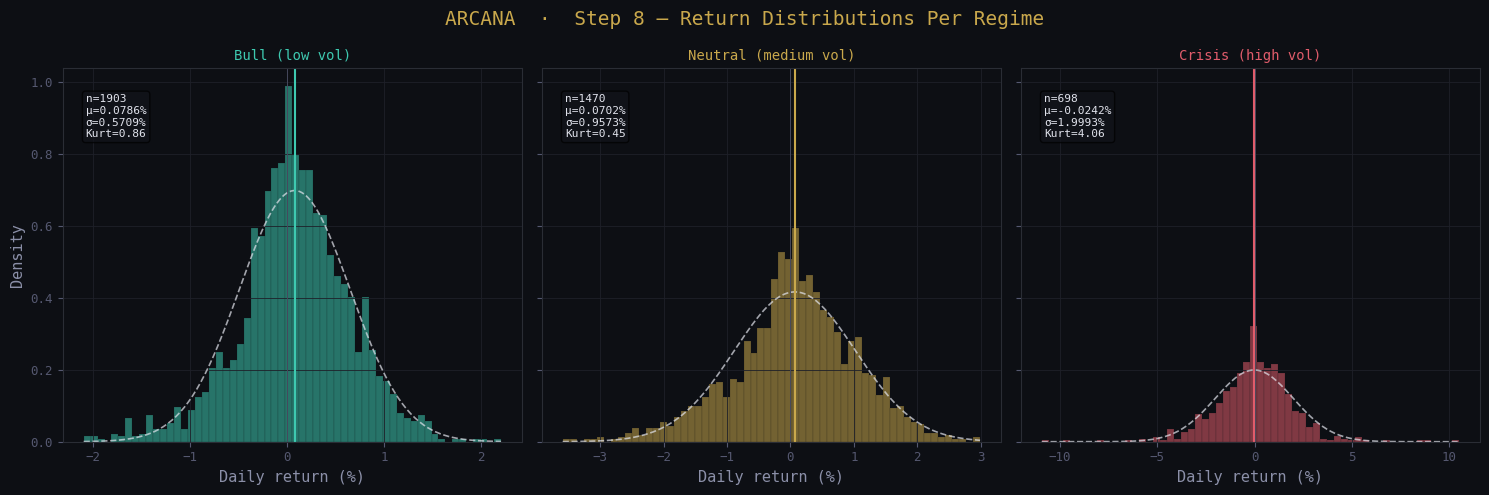

✓ Chart saved: viz_step8_regime_distributions.png


In [19]:
# ── Visualise: per-regime return distributions ────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
fig.suptitle('ARCANA  ·  Step 8 — Return Distributions Per Regime',
             color=C_GOLD, fontsize=14)

for r in range(N_STATES):
    ax   = axes[r]
    mask = filtered_labels == r
    ret  = spy_ret[mask].values.astype(float) * 100
    color = REGIME_COLORS[r]

    ax.hist(ret, bins=60, color=color, alpha=0.55, density=True,
            edgecolor='#0d0f14', linewidth=0.2)

    # Normal fit overlay
    if len(ret) > 10:
        xr = np.linspace(ret.min(), ret.max(), 200)
        ax.plot(xr, stats.norm.pdf(xr, ret.mean(), ret.std()),
                color=C_WHITE, linewidth=1.2, linestyle='--', alpha=0.7)

    ax.axvline(0, color=C_GREY, linewidth=0.5)
    ax.axvline(ret.mean(), color=color, linewidth=1.5,
               label=f'Mean={ret.mean():.3f}%')

    kur = float(stats.kurtosis(ret, fisher=True)) if len(ret) > 4 else 0
    ax.set_title(REGIME_NAMES[r], color=color, fontsize=10)
    ax.set_xlabel('Daily return (%)')
    ax.text(0.05, 0.93,
            f'n={mask.sum()}\nμ={ret.mean():.4f}%\nσ={ret.std():.4f}%\nKurt={kur:.2f}',
            transform=ax.transAxes, fontsize=8, color=C_WHITE,
            verticalalignment='top',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#12141a', alpha=0.7))

axes[0].set_ylabel('Density')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'viz_step8_regime_distributions.png'),
            dpi=150, bbox_inches='tight', facecolor='#0d0f14')
plt.show()
print('✓ Chart saved: viz_step8_regime_distributions.png')

---
## Step 9 · Option A — Smooth Probability Approach (Daily Resolution)

**What:** Use the continuous regime probability vector `[P_bull, P_neutral, P_crisis]` directly for signal blending in Stage 5.  
**Why:** Hard labels flicker daily because markets are genuinely noisy. Probabilities carry the same information but smoothly — no whipsawing.  
**Used for:** Stage 5 signal weighting (`w = base_weight × regime_prob`)  

Output: `regime_probs_smoothed.csv`

In [ ]:
# ── Option A: Exponentially weighted smoothing of regime probabilities ────
# Raw forward-algorithm probs already carry uncertainty — we smooth further
# with a short EWM span to reduce day-to-day noise without losing regime signal

SMOOTH_SPAN = 5   # 5-day EWM halflife — adjust if needed

probs_df = pd.DataFrame(
    reordered_probs,
    index=dates,
    columns=['P_bull', 'P_neutral', 'P_crisis']
)

# Apply EWM smoothing per column
probs_smoothed = probs_df.ewm(span=SMOOTH_SPAN, adjust=False).mean()

# Renormalise rows to sum to 1 after smoothing
row_sums = probs_smoothed.sum(axis=1)
probs_smoothed = probs_smoothed.div(row_sums, axis=0)

# Dominant regime from smoothed probs
dominant_regime_A = probs_smoothed.values.argmax(axis=1)

# Save
probs_smoothed.to_csv(os.path.join(OUTPUT_DIR, 'regime_probs_smoothed.csv'))
print(f'✓ regime_probs_smoothed.csv saved  — shape {probs_smoothed.shape}')

# Stats from smoothed dominant regime
spy_ret_vals = market['spy_return'].values
print(f'\nOption A — Smoothed probability dominant regime stats:')
print(f'{"Regime":<30} {"Days":>6} {"Freq":>7} {"Avg Ret":>10} {"Avg Vol":>10}')
print('-' * 68)
for r in range(N_STATES):
    mask = dominant_regime_A == r
    avg  = spy_ret_vals[mask].mean() * 100
    vol  = market['spy_vol_20d_raw'].values[mask].mean() * 100
    print(f'{REGIME_NAMES[r]:<30} {mask.sum():>6} {mask.sum()/len(mask):>7.1%} {avg:>10.4f}% {vol:>10.4f}%')

print(f'\nSmoothing span: {SMOOTH_SPAN} days (EWM)')
print(f'Regime switches (smoothed): {int((np.diff(dominant_regime_A) != 0).sum())}')
print(f'Regime switches (raw):      {int((np.diff(filtered_labels) != 0).sum())}')

In [ ]:
# ── Visualise Option A: raw vs smoothed probabilities ────────────────────
fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)
fig.suptitle('ARCANA  ·  Step 9 — Option A: Smoothed Regime Probabilities',
             color=C_GOLD, fontsize=14)

labels_col = ['P_bull', 'P_neutral', 'P_crisis']
colors_list = [REGIME_COLORS[0], REGIME_COLORS[1], REGIME_COLORS[2]]

for i, (col, color, name) in enumerate(zip(labels_col, colors_list, REGIME_NAMES.values())):
    ax = axes[i]
    # Raw probability (faint)
    ax.fill_between(dates, probs_df[col].values,
                    alpha=0.2, color=color, label='Raw')
    ax.plot(dates, probs_df[col].values,
            color=color, linewidth=0.5, alpha=0.4)
    # Smoothed probability (solid)
    ax.plot(dates, probs_smoothed[col].values,
            color=color, linewidth=1.5, label=f'EWM({SMOOTH_SPAN}d)')
    ax.set_ylabel('Probability')
    ax.set_title(f'{name}', color=color, fontsize=10)
    ax.set_ylim(0, 1)
    ax.legend(loc='upper right', fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.set_xlim(dates[0], dates[-1])

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'viz_step9_optionA_smoothed_probs.png'),
            dpi=150, bbox_inches='tight', facecolor='#0d0f14')
plt.show()
print('✓ Chart saved: viz_step9_optionA_smoothed_probs.png')

---
## Step 10 · Option B — Weekly Resampling (Cleaner Regime Blocks)

**What:** Resample features to weekly frequency before HMM training.  
**Why:** Weekly aggregation smooths daily noise → larger coherent regime blocks, closer to Wang et al. Figure 4.  
**Trade-off:** Lose daily resolution for signal gating. Weekly labels are interpolated back to daily for Stage 4.  

Output: `regime_labels_weekly.csv`, `regime_probs_weekly.csv`

In [ ]:
# ── Option B: Weekly resampling → retrain HMM → map back to daily ────────

# Step B1: resample features to weekly (Friday close)
X_weekly = X_raw.resample('W-FRI').agg({
    'spy_return'     : 'sum',    # sum daily returns = weekly return
    'spy_vol_20d_raw': 'mean',   # average vol over week
    'xs_dispersion'  : 'mean',   # average dispersion over week
}).dropna()

print(f'Weekly data shape : {X_weekly.shape}')
print(f'Date range        : {X_weekly.index[0].date()}  →  {X_weekly.index[-1].date()}')

# Step B2: scale weekly features
scaler_w   = StandardScaler()
X_weekly_scaled = scaler_w.fit_transform(X_weekly.values)

# Step B3: train HMM on weekly data
print(f'\nTraining weekly HMM ({N_INIT} restarts)...')
best_model_w = None
best_score_w = -np.inf

def make_sticky_transmat(n, sticky=0.97):
    T = np.full((n, n), (1 - sticky) / (n - 1))
    np.fill_diagonal(T, sticky)
    return T

for i in range(N_INIT):
    seed = RANDOM_STATE + i
    m = GaussianHMM(
        n_components    = N_STATES,
        covariance_type = 'full',
        n_iter          = N_ITER,
        tol             = 1e-6,
        min_covar       = 0.005,
        random_state    = seed
    )
    m.transmat_ = make_sticky_transmat(N_STATES, sticky=0.97)
    m.fit(X_weekly_scaled)
    s = m.score(X_weekly_scaled)
    if s > best_score_w:
        best_score_w = s
        best_model_w = m
    print(f'  Restart {i+1:>2}/{N_INIT}  log-likelihood={s:.4f}  {"← best" if s == best_score_w else ""}')

# Step B4: decode weekly states
_, raw_states_w = best_model_w.decode(X_weekly_scaled, algorithm='viterbi')
raw_probs_w     = best_model_w.predict_proba(X_weekly_scaled)

# Step B5: map states by return (same logic as daily)
ret_means_w = best_model_w.means_[:, HMM_FEATURES.index('spy_return')]
vol_means_w = best_model_w.means_[:, HMM_FEATURES.index('spy_vol_20d_raw')]

crisis_raw_w  = int(np.argmin(ret_means_w))
remaining_w   = [i for i in range(N_STATES) if i != crisis_raw_w]
vol_rem_w     = sorted([(i, vol_means_w[i]) for i in remaining_w], key=lambda x: x[1])
bull_raw_w    = vol_rem_w[0][0]
neutral_raw_w = vol_rem_w[1][0]
state_map_w   = {bull_raw_w: 0, neutral_raw_w: 1, crisis_raw_w: 2}

labelled_w = np.array([state_map_w[s] for s in raw_states_w])
reordered_probs_w = np.zeros_like(raw_probs_w)
for raw, label in state_map_w.items():
    reordered_probs_w[:, label] = raw_probs_w[:, raw]

# Step B6: forward-fill weekly labels back to daily index
weekly_label_series = pd.Series(labelled_w, index=X_weekly.index, name='regime')
weekly_probs_df     = pd.DataFrame(reordered_probs_w, index=X_weekly.index,
                                    columns=['P_bull', 'P_neutral', 'P_crisis'])

# Reindex to daily, forward-fill
daily_labels_w = weekly_label_series.reindex(dates, method='ffill').fillna(method='bfill')
daily_probs_w  = weekly_probs_df.reindex(dates, method='ffill').fillna(method='bfill')

# Save
daily_labels_w.to_csv(os.path.join(OUTPUT_DIR, 'regime_labels_weekly.csv'))
daily_probs_w.to_csv(os.path.join(OUTPUT_DIR, 'regime_probs_weekly.csv'))

print(f'\n✓ Weekly HMM complete')
print(f'  Best log-likelihood: {best_score_w:.4f}')
print(f'  Regime switches (weekly→daily): {int((np.diff(daily_labels_w.values) != 0).sum())}')
print(f'  Regime switches (daily model):  {int((np.diff(filtered_labels) != 0).sum())}')

print(f'\nOption B — Weekly regime stats:')
spy_ret_vals = market["spy_return"].values
print(f'{"Regime":<30} {"Days":>6} {"Freq":>7} {"Avg Ret":>10} {"Avg Vol":>10}')
print('-' * 68)
for r in range(N_STATES):
    mask = daily_labels_w.values == r
    avg  = spy_ret_vals[mask].mean() * 100
    vol  = market['spy_vol_20d_raw'].values[mask].mean() * 100
    print(f'{REGIME_NAMES[r]:<30} {mask.sum():>6} {mask.sum()/len(mask):>7.1%} {avg:>10.4f}% {vol:>10.4f}%')

In [ ]:
# ── Visualise Option B: weekly regime on SPY price ────────────────────────
spy_prices_b = pd.read_csv(
    os.path.join(r'C:\Arbion Research\Stage 1 data layer\Universe_stock data', 'SPY.csv'),
    parse_dates=['Date']
).rename(columns={'Date': 'date'}).set_index('date').sort_index()
spy_prices_b = spy_prices_b.loc[dates[0]:dates[-1]]
spy_aligned_b = spy_prices_b['Close'].reindex(dates).ffill()

fig, axes = plt.subplots(3, 1, figsize=(16, 11),
                          gridspec_kw={'height_ratios': [3, 1.2, 1.2]})
fig.suptitle('ARCANA  ·  Step 10 — Option B: Weekly HMM (Cleaner Regime Blocks)',
             color=C_GOLD, fontsize=14)

# Panel 1: SPY price with weekly regime shading
ax1 = axes[0]
ax1.plot(dates, spy_aligned_b.values, color=C_WHITE, linewidth=1.2, zorder=3)
for r in range(N_STATES):
    mask  = daily_labels_w.values == r
    color = REGIME_COLORS[r]
    in_block, start = False, None
    for i, (d, m) in enumerate(zip(dates, mask)):
        if m and not in_block:
            start = d; in_block = True
        elif not m and in_block:
            ax1.axvspan(start, d, alpha=0.22, color=color, zorder=1)
            in_block = False
    if in_block:
        ax1.axvspan(start, dates[-1], alpha=0.22, color=color, zorder=1)

ax1.set_ylabel('SPY Close Price ($)')
ax1.set_title('SPY price — weekly HMM regime background', color=C_WHITE, fontsize=10)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax1.set_xlim(dates[0], dates[-1])
legend_patches = [mpatches.Patch(color=REGIME_COLORS[r], alpha=0.6,
                  label=REGIME_NAMES[r]) for r in range(N_STATES)]
ax1.legend(handles=legend_patches, loc='upper left', fontsize=9)

# Panel 2: weekly probability stack
ax2 = axes[1]
ax2.stackplot(dates,
    daily_probs_w['P_bull'].values,
    daily_probs_w['P_neutral'].values,
    daily_probs_w['P_crisis'].values,
    colors=[REGIME_COLORS[0], REGIME_COLORS[1], REGIME_COLORS[2]],
    alpha=0.75, labels=['Bull', 'Neutral', 'Crisis']
)
ax2.set_ylabel('Probability')
ax2.set_title('Weekly regime probability stack (forward-filled to daily)',
              color=C_WHITE, fontsize=10)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax2.set_xlim(dates[0], dates[-1])
ax2.set_ylim(0, 1)
ax2.legend(loc='upper right', fontsize=8, ncol=3)

# Panel 3: side-by-side comparison — daily vs weekly label
ax3 = axes[2]
# Top half: daily
daily_colors = [REGIME_COLORS[r] for r in filtered_labels]
ax3.bar(dates, np.full(len(dates), 0.45), bottom=0.55,
        color=daily_colors, width=1.5, alpha=0.9)
# Bottom half: weekly
weekly_colors = [REGIME_COLORS[int(r)] for r in daily_labels_w.values]
ax3.bar(dates, np.full(len(dates), 0.45), bottom=0.05,
        color=weekly_colors, width=1.5, alpha=0.9)

ax3.set_yticks([0.275, 0.775])
ax3.set_yticklabels(['Weekly', 'Daily'], fontsize=8, color='#8b8fa8')
ax3.set_title('Daily (top) vs Weekly (bottom) regime labels — comparison',
              color=C_WHITE, fontsize=10)
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax3.set_xlim(dates[0], dates[-1])

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'viz_step10_optionB_weekly.png'),
            dpi=150, bbox_inches='tight', facecolor='#0d0f14')
plt.show()
print('✓ Chart saved: viz_step10_optionB_weekly.png')

---
## Step 11 · Comparison & Decision

| | Option A (daily + smoothed probs) | Option B (weekly resampled) |
|---|---|---|
| Resolution | Daily | Weekly → forward-filled daily |
| Regime switches | Fewer (EWM smoothed) | Much fewer (weekly blocks) |
| Used for Stage 4 | Signal gating via prob threshold | Signal gating via hard label |
| Used for Stage 5 | Continuous prob weights | Step-function weights |
| Recommended for | Live trading (smooth sizing) | Research / backtesting |

**Arcana uses both:** Option A probabilities feed Stage 5 signal blending. Option B labels feed Stage 4 signal gating (cleaner on/off switches for pair trading).

In [ ]:
# ── Visualise: 3-way comparison of regime approaches ─────────────────────
fig, axes = plt.subplots(3, 1, figsize=(16, 9), sharex=True)
fig.suptitle('ARCANA  ·  Step 11 — Regime Approach Comparison',
             color=C_GOLD, fontsize=14)

row_data = [
    ('Daily hard labels (raw)',       filtered_labels,           'hard'),
    ('Option A — smoothed probs dominant', dominant_regime_A,   'hard'),
    ('Option B — weekly resampled',   daily_labels_w.values,    'hard'),
]

for ax, (title, labels, mode) in zip(axes, row_data):
    colors_ts = [REGIME_COLORS[int(r)] for r in labels]
    ax.bar(dates, np.ones(len(dates)), color=colors_ts, width=1.5, alpha=0.9)
    switches = int((np.diff(labels.astype(int) if hasattr(labels, 'astype') else np.array(labels)) != 0).sum())
    ax.set_title(f'{title}  —  {switches} regime switches', color=C_WHITE, fontsize=10)
    ax.set_yticks([])
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.set_xlim(dates[0], dates[-1])

legend_patches = [mpatches.Patch(color=REGIME_COLORS[r], alpha=0.7,
                  label=REGIME_NAMES[r]) for r in range(N_STATES)]
axes[0].legend(handles=legend_patches, loc='upper right', fontsize=8, ncol=3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'viz_step11_regime_comparison.png'),
            dpi=150, bbox_inches='tight', facecolor='#0d0f14')
plt.show()
print('✓ Chart saved: viz_step11_regime_comparison.png')

print(f'\nRegime switch summary:')
print(f'  Daily hard labels    : {int((np.diff(filtered_labels) != 0).sum())} switches')
print(f'  Option A (smoothed)  : {int((np.diff(dominant_regime_A) != 0).sum())} switches')
print(f'  Option B (weekly)    : {int((np.diff(daily_labels_w.values.astype(int)) != 0).sum())} switches')
print(f'\n✓ Stage 3 fully complete — 3 regime outputs available for Stage 4')

In [1]:
# Run in Stage 3 notebook — paste output here
import numpy as np
import pandas as pd

regime_labels = pd.read_csv(r'C:\Arbion Research\Stage 3 HMM regime engine\regime_labels_weekly.csv',
                             index_col=0, parse_dates=True).squeeze()
net_ret = pd.read_csv(r'C:\Arbion Research\Stage 7 risk management\net_returns.csv',
                       index_col=0, parse_dates=True).squeeze()
net_ret = net_ret[net_ret != 0]

regime_daily = regime_labels.reindex(net_ret.index, method='ffill')

print('HMM State Statistics:')
print(f'{"Regime":<10} {"% Days":>8} {"Mean Ret (ann)":>15} {"Vol (ann)":>12}')
print('-'*50)
for r, name in [(0,'Bull'),(1,'Neutral'),(2,'Crisis')]:
    mask = regime_daily == r
    r_ret = net_ret[mask]
    pct   = mask.mean()*100
    ann_r = r_ret.mean()*252*100
    ann_v = r_ret.std()*np.sqrt(252)*100
    print(f'{name:<10} {pct:>8.1f}% {ann_r:>15.2f}% {ann_v:>12.2f}%')

print('\nTransition matrix (weekly):')
rl = regime_labels.values.astype(int)
mat = np.zeros((3,3))
for t in range(len(rl)-1):
    f,to=rl[t],rl[t+1]
    if 0<=f<=2 and 0<=to<=2: mat[f,to]+=1
mat = mat/mat.sum(axis=1,keepdims=True)
labels=['Bull','Neutral','Crisis']
print(f'{"":>10}', '  '.join(f'{l:>8}' for l in labels))
for i,l in enumerate(labels):
    print(f'{l:>10}', '  '.join(f'{mat[i,j]:>8.3f}' for j in range(3)))

HMM State Statistics:
Regime       % Days  Mean Ret (ann)    Vol (ann)
--------------------------------------------------
Bull           59.5%           21.10%         7.57%
Neutral        40.2%           21.94%         7.59%
Crisis          0.3%          -22.23%         0.46%

Transition matrix (weekly):
               Bull   Neutral    Crisis
      Bull    0.981     0.019     0.000
   Neutral    0.023     0.970     0.007
    Crisis    0.000     0.013     0.987
